# EC1036 - Inteligência Computacional
## Tópico: Agrupamento e detecção de anomalias

## Introdução a agrupamento 

Até aqui, exploramos métodos de classificação e regressão, que utilizam dados rotulados para construir modelos preditivos. Em resumo, enquanto a classificação busca prever categorias discretas, a regressão foca em valores contínuos. Em ambos os casos, os rótulos são necessários previamente para o treinamento dos modelos.

As técnicas de agrupamento (clustering) operam sob uma lógica distinta, pois elas trabalham com dados **não rotulados**. Isso altera fundamentalmente a maneira como o algoritmo aprende, deslocando o foco da "predição de um alvo" para a "exploração de estruturas ocultas".

---

**O que é Clustering?**

O clustering é uma técnica de aprendizado não supervisionado que visa identificar comportamentos semelhantes entre registros, organizando-os em grupos denominados clusters. Por não depender de categorias predefinidas, essa abordagem é utilizada para descobrir padrões e tendências em grandes volumes de dados que não seriam aparentes à primeira vista.



## O Algoritmo K-Means

O K-Means é um algoritmo iterativo que visa particionar um conjunto de dados em $K$ clusters distintos. Ele faz isso agrupando os pontos de dados em torno de centroids (centros de clusters) que representam o “centro” de cada grupo. O algoritmo procura minimizar a soma das distâncias quadradas entre os pontos de dados e os centroids, garantindo que os pontos dentro de um mesmo cluster sejam o mais semelhante possível.

O algoritmo K-Means funciona basicamente da seguinte forma:

1. **Escolha o número de clusters (K):** Inicialmente, você precisa definir quantos clusters o algoritmo deve formar, por exemplo, K=3. O valor de K pode variar de acordo com o problema ou os dados que você está analisando.

2. **Inicialize os centroids:** O algoritmo seleciona aleatoriamente K pontos do conjunto de dados para serem os centroids iniciais. Esses centroids servem como os centros iniciais dos clusters.

3. **Atribuição dos pontos aos clusters:** Cada ponto do conjunto de dados é atribuído ao centroid mais próximo, formando assim K clusters. A proximidade é medida com base na distância euclidiana.

4. **Atualização dos centroids:** Após a atribuição dos pontos, o centro de cada cluster é recalculado como a média de todos os pontos pertencentes a esse cluster. Os centroids são atualizados de acordo com essa nova posição.

5. **Repetição:** O processo de atribuição e atualização é repetido até que os centroids não se movam mais significativamente, ou seja, até que os clusters se estabilizem.

6. **Convergência:** O algoritmo para quando não há mais mudanças significativas na posição dos centroids ou quando o número máximo de iterações definido é atingido. O resultado final é um conjunto de K clusters, cada um com seu respectivo centroid.

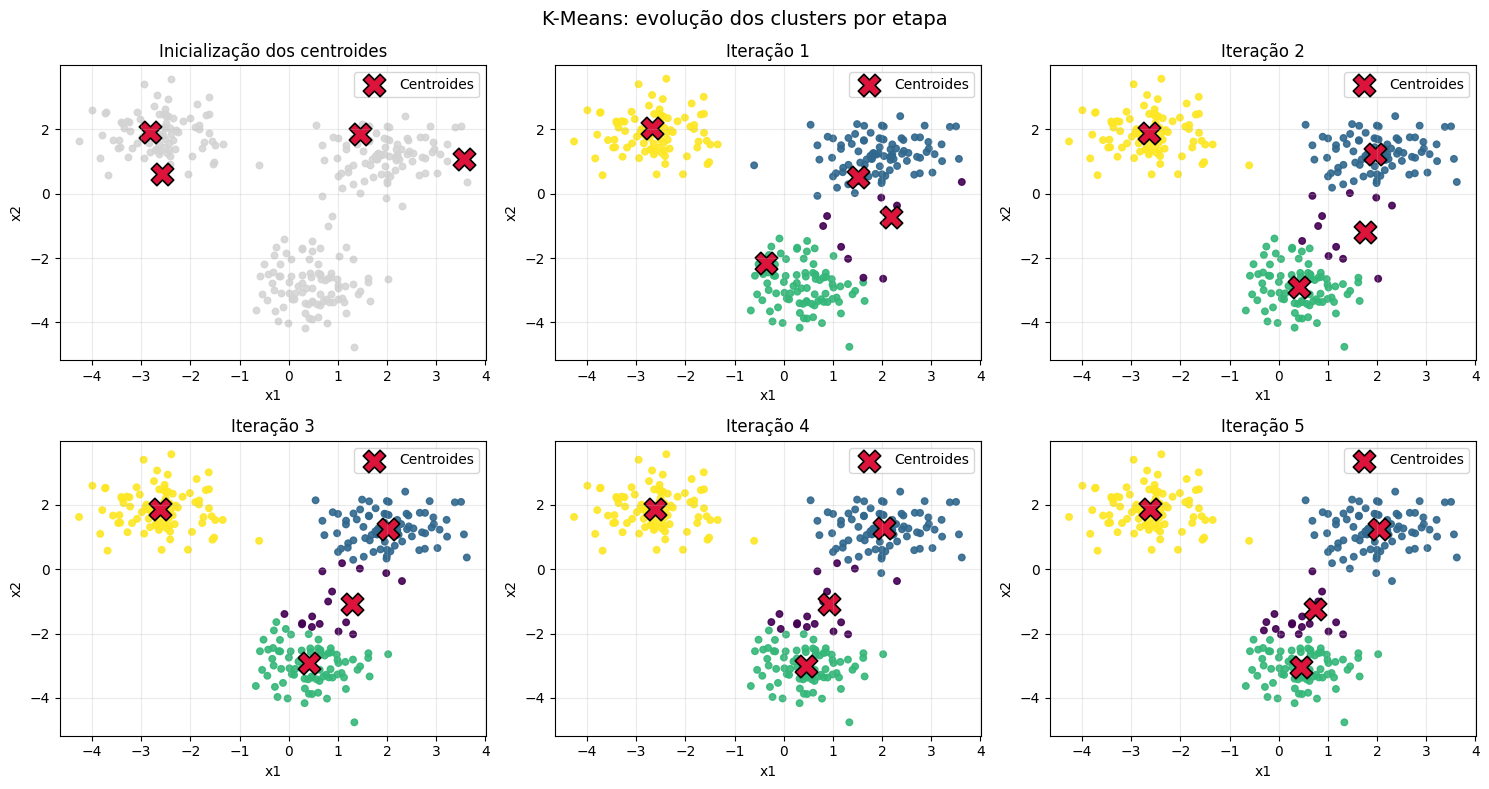

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

random_generator = np.random.default_rng(7)

cluster_a = random_generator.normal(loc=[-2.5, 2.0], scale=[0.7, 0.7], size=(90, 2))
cluster_b = random_generator.normal(loc=[2.0, 1.2], scale=[0.8, 0.6], size=(90, 2))
cluster_c = random_generator.normal(loc=[0.5, -2.5], scale=[0.6, 0.8], size=(90, 2))
samples = np.vstack([cluster_a, cluster_b, cluster_c])

number_of_clusters = 4
maximum_iterations = 5

initial_indices = random_generator.choice(len(samples), size=number_of_clusters, replace=False)
centroids = samples[initial_indices].copy()

history = [{
    "labels": None,
    "centroids": centroids.copy(),
    "title": "Inicialização dos centroides"
}]

for iteration_index in range(1, maximum_iterations + 1):
    kmeans = KMeans(
        n_clusters=number_of_clusters,  # número de clusters (K)
        init=centroids,                 # centroides iniciais da iteração atual
        n_init=1,                       # quantidade de inicializações (1 para usar só estes centroides)
        max_iter=1,                     # executa apenas 1 iteração por passagem do for
        algorithm="lloyd",              # método de otimização do K-Means (distância euclidiana)
        random_state=7                  # semente para manter resultados reproduzíveis
    )

    labels = kmeans.fit_predict(samples)
    new_centroids = kmeans.cluster_centers_

    history.append({
        "labels": labels.copy(),
        "centroids": new_centroids.copy(),
        "title": f"Iteração {iteration_index}"
    })

    if np.allclose(new_centroids, centroids):
        break

    centroids = new_centroids

number_of_plots = len(history)
number_of_columns = 3
number_of_rows = int(np.ceil(number_of_plots / number_of_columns))

figure, axes = plt.subplots(number_of_rows, number_of_columns, figsize=(5 * number_of_columns, 4 * number_of_rows))
axes = np.array(axes).reshape(-1)

for axis_index, axis in enumerate(axes):
    if axis_index >= number_of_plots:
        axis.axis("off")
        continue

    step = history[axis_index]
    step_labels = step["labels"]

    if step_labels is None:
        axis.scatter(samples[:, 0], samples[:, 1], s=22, color="lightgray", alpha=0.85)
    else:
        axis.scatter(samples[:, 0], samples[:, 1], c=step_labels, cmap="viridis", s=22, alpha=0.9)

    axis.scatter(
        step["centroids"][:, 0],
        step["centroids"][:, 1],
        color="crimson",
        marker="X",
        s=260,
        edgecolor="black",
        linewidth=1.2,
        label="Centroides"
    )

    axis.set_title(step["title"])
    axis.set_xlabel("x1")
    axis.set_ylabel("x2")
    axis.legend(loc="best")
    axis.grid(alpha=0.25)

plt.suptitle("K-Means: evolução dos clusters por etapa", fontsize=14)
plt.tight_layout()
plt.show()

A imagem mostra a evolução do K-Means ao longo das iterações. No primeiro painel, os centroides são inicializados em posições aleatórias; em seguida, cada ponto é atribuído ao centroide mais próximo e as cores passam a representar os clusters formados. A cada iteração, os centroides se deslocam para o centro de seus grupos até estabilizarem, indicando a convergência do algoritmo e a separação final dos três clusters.

## Encontrando o número ótimo de de clusters

Encontrar o número ótimo de clusters é uma das partes mais desafiadoras do agrupamento, porque **não existe uma resposta universal**. Diferente de problemas supervisionados, no clustering não há rótulos verdadeiros para confirmar se a separação está “certa”. Assim, a escolha de $K$ depende de critérios estatísticos, interpretação do contexto e objetivo da análise.

Alguns fatores tornam essa decisão complexa:

- **Trade-off entre simplicidade e detalhe:** poucos clusters podem misturar grupos diferentes; muitos clusters podem fragmentar padrões que deveriam estar juntos.
- **Sensibilidade a escala, ruído e outliers:** pequenas mudanças nos dados podem alterar a estrutura dos grupos.
- **Forma dos clusters:** algoritmos como K-Means assumem clusters aproximadamente esféricos e de tamanho parecido; quando isso não ocorre, o “$K$ ótimo” pode ser enganoso.
- **Estabilidade da solução:** diferentes inicializações podem levar a partições distintas, especialmente em dados mais complexos.

Na prática, a escolha de $K$ costuma ser um processo iterativo: combinar métricas quantitativas com visualizações e validar se os grupos fazem sentido para o problema real. Ou seja, mais do que buscar um único número “perfeito”, o objetivo é encontrar um valor de $K$ que seja **estatisticamente consistente e útil para a tomada de decisão**.

## Inércia e Silhouette Score

Quando usamos K-Means, precisamos de critérios para avaliar se a separação em clusters ficou boa. Duas métricas muito usadas são a **Inércia** e o **Silhouette Score**.

**1) Inércia (Inertia)**

A inércia mede o quanto os pontos de cada cluster estão próximos do seu centróide. Em outras palavras, ela mede a **compactação interna** dos grupos.

Fórmula da inércia:

$$
\text{Inércia} = \sum_{i=1}^{n} \left\|x_i - \mu_{c_i}\right\|^2
$$

Onde:
- $x_i$: ponto $i$ do conjunto de dados
- $\mu_{c_i}$: centróide do cluster ao qual o ponto $x_i$ foi atribuído
- $n$: número total de pontos

**Interpretação:**
- Quanto **menor** a inércia, mais compactos estão os clusters.
- A inércia quase sempre diminui quando aumentamos \(K\), então ela **não deve ser usada sozinha**.
- Por isso, observamos o gráfico do cotovelo: buscamos o ponto em que a queda deixa de ser acentuada (ganho marginal menor).

---

**2) Silhouette Score**

O Silhouette Score avalia simultaneamente:
- **Coesão:** quão perto um ponto está dos pontos do seu próprio cluster.
- **Separação:** quão longe esse ponto está dos pontos dos outros clusters.

Para cada ponto $i$:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}
$$

Onde:
- $a(i)$: distância média do ponto $i$ para os pontos do mesmo cluster
- $b(i)$: menor distância média do ponto $i$ para pontos de outro cluster (cluster vizinho mais próximo)

O **Silhouette Score final** é a média de $s(i)$ para todos os pontos.

Faixa de valores: \([-1, 1]\).
- Próximo de **1**: clusters bem separados e compactos.
- Próximo de **0**: clusters sobrepostos ou mal definidos.
- Menor que **0**: muitos pontos podem estar no cluster errado.

---

**Como usar as duas métricas juntas na prática**

1. Teste vários valores de $K$.
2. No gráfico de inércia, procure um **cotovelo**.
3. No gráfico de silhouette, prefira valores de $K$ com score mais alto.
4. Escolha um $K$ que combine boa métrica com interpretação útil para o problema.

<br>

A seguir, demonstramos na prática como utilizar essas duas métricas com os dados já carregados:

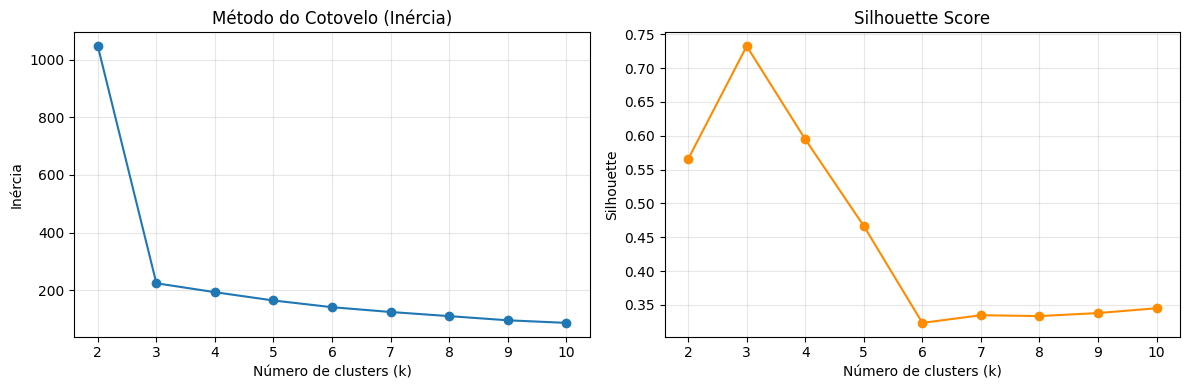

In [12]:
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=7, n_init=10)
    cluster_labels = model.fit_predict(samples)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(samples, cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Método do Cotovelo (Inércia)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Com base nos gráficos, a melhor escolha neste exemplo é **$K = 3$**.

**Por quê?**
- No **método do cotovelo**, há uma queda muito forte da inércia de $K=2$ para $K=3$.
- A partir de $K=3$, a redução da inércia continua, mas com ganhos menores (retorno decrescente).
- No **Silhouette Score**, o maior valor também ocorre em $K=3$, indicando melhor equilíbrio entre coesão interna e separação entre clusters.

Assim, $K=3$ oferece o melhor compromisso entre qualidade da segmentação e simplicidade do modelo para este conjunto de dados.